# Amplitude envelope (AE)
# Root mean square energy (RMS)
# Zero-crossing rate (ZCR)

In [ ]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
def plot_amplitude_envelope_with_frames(
    file_path: str,
    start_sec: float = 1.0,
    duration_sec: float = 0.05,  # Chọn đoạn ngắn (VD: 50ms) để quan sát rõ từng khung
    frame_size: int = 256,
    hop_length: int = 128,
):
    """Tính toán Amplitude Envelope (AE), vẽ khung (frame) và khoanh tròn điểm AE của từng khung.

    Parameters:
    - file_path: Đường dẫn tới file .mp3
    - start_sec: Thời điểm bắt đầu trích xuất âm thanh (giây)
    - duration_sec: Độ dài đoạn âm thanh quan sát (giây)
    - frame_size: Độ rộng khung tính toán (số mẫu)
    - hop_length: Bước nhảy giữa các khung (số mẫu)
    """
    # 1. Load file MP3 và lấy mẫu một đoạn ngắn
    y_full, sr = librosa.load(file_path, sr=None, mono=True)

    start_sample = int(start_sec * sr)
    num_samples = int(duration_sec * sr)
    y = y_full[start_sample : start_sample + num_samples]

    # Trục thời gian tính bằng mili giây (ms)
    t = np.linspace(0, duration_sec * 1000, len(y))

    # 2. Chia khung và tính giá trị AE cùng vị trí đỉnh của từng khung
    ae_values = []
    ae_times_ms = []
    frame_edges = []

    for i in range(0, len(y) - frame_size + 1, hop_length):
        frame_samples = y[i : i + frame_size]

        # Vị trí cực đại local trong khung
        local_max_idx = np.argmax(np.abs(frame_samples))
        global_max_idx = i + local_max_idx

        # Giá trị AE = max(|x[n]|) trong khung
        ae_val = np.abs(frame_samples[local_max_idx])
        ae_time = t[global_max_idx]

        ae_values.append(ae_val)
        ae_times_ms.append(ae_time)

        # Lưu ranh giới bắt đầu và kết thúc của khung (theo ms)
        t_start = t[i]
        t_end = t[min(i + frame_size - 1, len(y) - 1)]
        frame_edges.append((t_start, t_end))

    # 3. Trực quan hóa biểu đồ
    plt.figure(figsize=(14, 6))

    # A. Vẽ dạng sóng tín hiệu gốc (Waveform)
    plt.plot(
        t,
        y,
        color="#1f77b4",
        alpha=0.6,
        linewidth=1.2,
        label="Tín hiệu dạng sóng (Waveform)",
    )

    # B. Vẽ các Khung (Frame) và đường ranh giới
    colors = ["#f0f4f8", "#ffffff"]  # Màu nền đan xen giữa các khung
    max_amplitude = np.max(np.abs(y)) * 1.3

    for idx, (start_t, end_t) in enumerate(frame_edges):
        # Tô màu phân biệt vùng của từng khung
        plt.axvspan(start_t, end_t, color=colors[idx % 2], alpha=0.6)

        # Vẽ đường ranh giới dọc nét đứt cho đầu khung
        plt.axvline(x=start_t, color="#888888", linestyle="--", alpha=0.7)

        # Đánh nhãn tên khung (F1, F2, F3...) ở đỉnh đồ thị
        center_t = (start_t + end_t) / 2
        plt.text(
            center_t,
            max_amplitude * 0.88,
            f"F{idx+1}",
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=9,
            fontweight="bold",
            color="#2b3e50",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="#cccccc",
                alpha=0.9,
            ),
        )

    # Đường ranh giới khung cuối cùng
    if frame_edges:
        plt.axvline(
            x=frame_edges[-1][1], color="#888888", linestyle="--", alpha=0.7
        )

    # C. Vẽ đường bao AE kết nối các điểm đỉnh
    plt.plot(
        ae_times_ms,
        ae_values,
        color="#d62728",
        linestyle="-",
        linewidth=2,
        label="Đường bao AE (Envelope)",
    )

    # D. Khoanh tròn các giá trị AE tại mỗi khung
    # Vòng tròn đỏ bên ngoài (Khoanh vùng điểm AE)
    plt.scatter(
        ae_times_ms,
        ae_values,
        s=200,
        facecolors="none",
        edgecolors="#d62728",
        linewidth=2.5,
        zorder=5,
        label="Giá trị AE từng khung (Khoanh tròn)",
    )

    # Chấm đỏ ở tâm điểm
    plt.scatter(ae_times_ms, ae_values, color="#d62728", s=35, zorder=6)

    # Giới hạn trục Y và định dạng biểu đồ
    plt.ylim(-max_amplitude, max_amplitude)
    plt.title(
        f"Phân tích Amplitude Envelope (AE) & Khoanh Vùng Từng Khung (FrameSize={frame_size}, Hop={hop_length})",
        fontsize=13,
        fontweight="bold",
    )
    plt.xlabel("Thời gian (ms)", fontsize=11)
    plt.ylabel("Biên độ (Amplitude)", fontsize=11)
    plt.legend(
        loc="lower right", frameon=True, facecolor="white", framealpha=0.9
    )
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

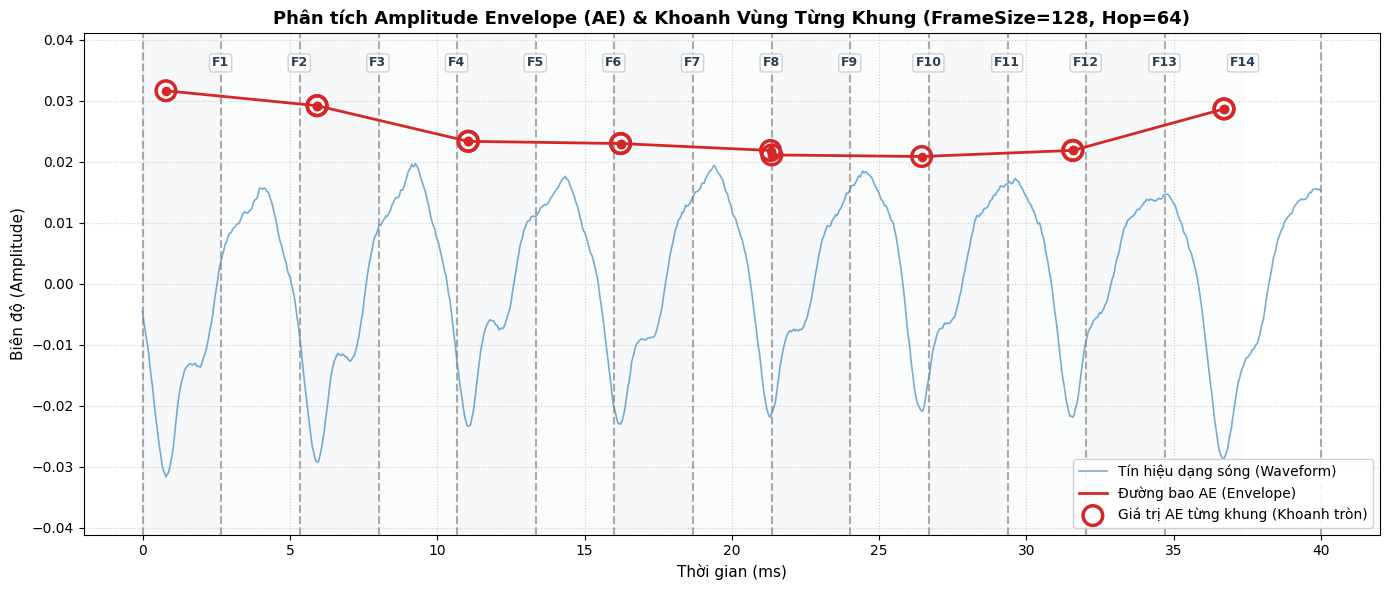

In [6]:
plot_amplitude_envelope_with_frames(r"E:\s-recognition\data\freesound_community-violin-spiccato-g2-91380.mp3", 
                                    start_sec=1.0, duration_sec=0.04, frame_size=128, hop_length=64)

In [ ]:
# RMS energy
def compute_rms_energy(
    file_path: str,
    frame_size: int = 1024,
    hop_length: int = 512,
    plot: bool = True,
):
    """Tính toán và trực quan hóa năng lượng RMS (Root Mean Square) từ file MP3.

    Parameters:
    - file_path: Đường dẫn tới file .mp3
    - frame_size: Độ rộng khung tính toán (số mẫu)
    - hop_length: Bước nhảy giữa các khung (số mẫu)
    - plot: Vẽ biểu đồ so sánh RMS với tín hiệu gốc
    """
    # 1. Load file âm thanh
    y, sr = librosa.load(file_path, sr=None, mono=True)

    # 2. Tính RMS Energy sử dụng Librosa
    # Trả về mảng 2D (1, num_frames), chuyển thành 1D bằng [0]
    rms = librosa.feature.rms(
        y=y, frame_length=frame_size, hop_length=hop_length
    )[0]

    # 3. Tạo trục thời gian cho tín hiệu gốc và cho giá trị RMS
    t_signal = librosa.samples_to_time(range(len(y)), sr=sr)
    t_rms = librosa.frames_to_time(
        range(len(rms)), sr=sr, hop_length=hop_length
    )

    # 4. Vẽ biểu đồ
    if plot:
        plt.figure(figsize=(12, 5))
        plt.plot(
            t_signal,
            y,
            alpha=0.35,
            color="#1f77b4",
            label="Tín hiệu dạng sóng (Waveform)",
        )
        plt.plot(
            t_rms,
            rms,
            color="#ff7f0e",
            linewidth=2,
            label="Năng lượng RMS (RMS Energy)",
        )

        plt.title(
            f"Phân tích RMS Energy (Frame Size={frame_size}, Hop={hop_length})",
            fontsize=12,
        )
        plt.xlabel("Thời gian (giây)")
        plt.ylabel("Biên độ / Năng lượng")
        plt.legend(loc="upper right")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.show()

    return rms, t_rms


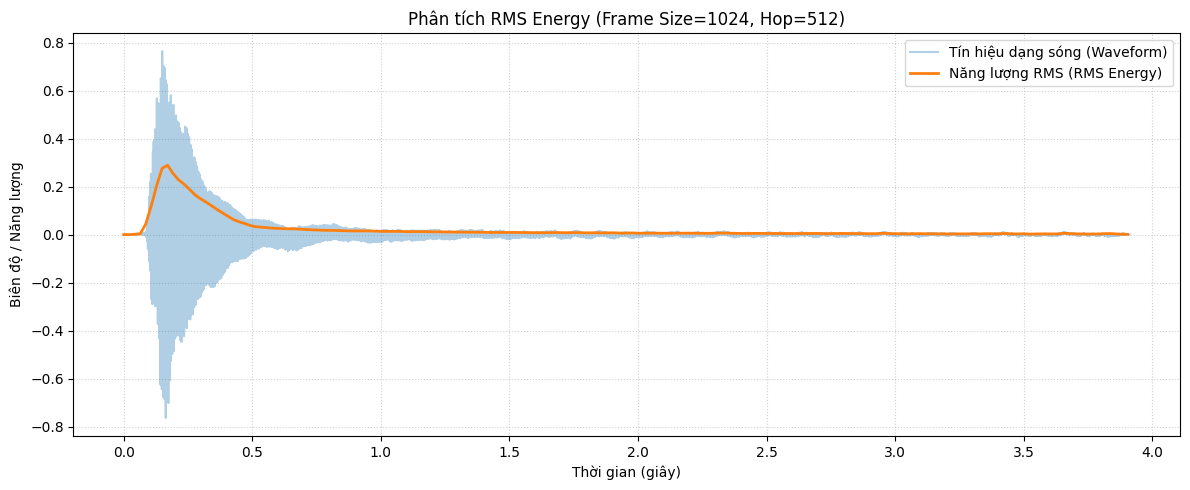

In [8]:
rms, t_rms = compute_rms_energy(r"E:\s-recognition\data\freesound_community-violin-spiccato-g2-91380.mp3", 
                                frame_size=1024, hop_length=512)

In [9]:
def visualize_zero_crossing_rate(
    file_path: str,
    frame_size: int = 1024,
    hop_length: int = 512,
    start_sec: float = None,
    duration_sec: float = None,
):
    """Tính toán và trực quan hóa Tỷ lệ qua điểm không (Zero Crossing Rate - ZCR).

    Parameters:
    - file_path: Đường dẫn tới file .mp3
    - frame_size: Độ rộng khung tính toán (mẫu)
    - hop_length: Bước nhảy giữa các khung (mẫu)
    - start_sec: Thời điểm bắt đầu trích xuất (giây, None nếu lấy toàn bộ)
    - duration_sec: Độ dài đoạn trích xuất (giây, None nếu lấy toàn bộ)
    """
    # 1. Load file âm thanh
    y, sr = librosa.load(file_path, sr=None, mono=True)

    # Cắt đoạn âm thanh nếu được yêu cầu
    if start_sec is not None and duration_sec is not None:
        start_sample = int(start_sec * sr)
        num_samples = int(duration_sec * sr)
        y = y[start_sample : start_sample + num_samples]

    # 2. Tính Zero Crossing Rate (ZCR)
    # Hàm trả về mảng 2D shape (1, num_frames), trích xuất [0] để thành mảng 1D
    zcr = librosa.feature.zero_crossing_rate(
        y=y, frame_length=frame_size, hop_length=hop_length
    )[0]

    # 3. Tạo trục thời gian cho Waveform và ZCR
    t_signal = librosa.samples_to_time(range(len(y)), sr=sr)
    t_zcr = librosa.frames_to_time(
        range(len(zcr)), sr=sr, hop_length=hop_length
    )

    # 4. Trực quan hóa đồ thị
    fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # Dạng sóng gốc (Waveform)
    axs[0].plot(
        t_signal,
        y,
        color="#1f77b4",
        alpha=0.6,
        linewidth=1,
        label="Waveform (Dạng sóng)",
    )
    axs[0].set_title("Tín hiệu âm thanh gốc")
    axs[0].set_ylabel("Biên độ")
    axs[0].grid(True, linestyle=":", alpha=0.6)
    axs[0].legend(loc="upper right")

    # Đồ thị Zero Crossing Rate
    axs[1].plot(
        t_zcr,
        zcr,
        color="#2ca02c",
        linewidth=2,
        label="Zero Crossing Rate (ZCR)",
    )
    axs[1].set_title(
        f"Biểu đồ Zero Crossing Rate (Frame Size={frame_size}, Hop={hop_length})"
    )
    axs[1].set_xlabel("Thời gian (giây)")
    axs[1].set_ylabel("Tỷ lệ (0 đến 1)")
    axs[1].grid(True, linestyle=":", alpha=0.6)
    axs[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    return zcr, t_zcr


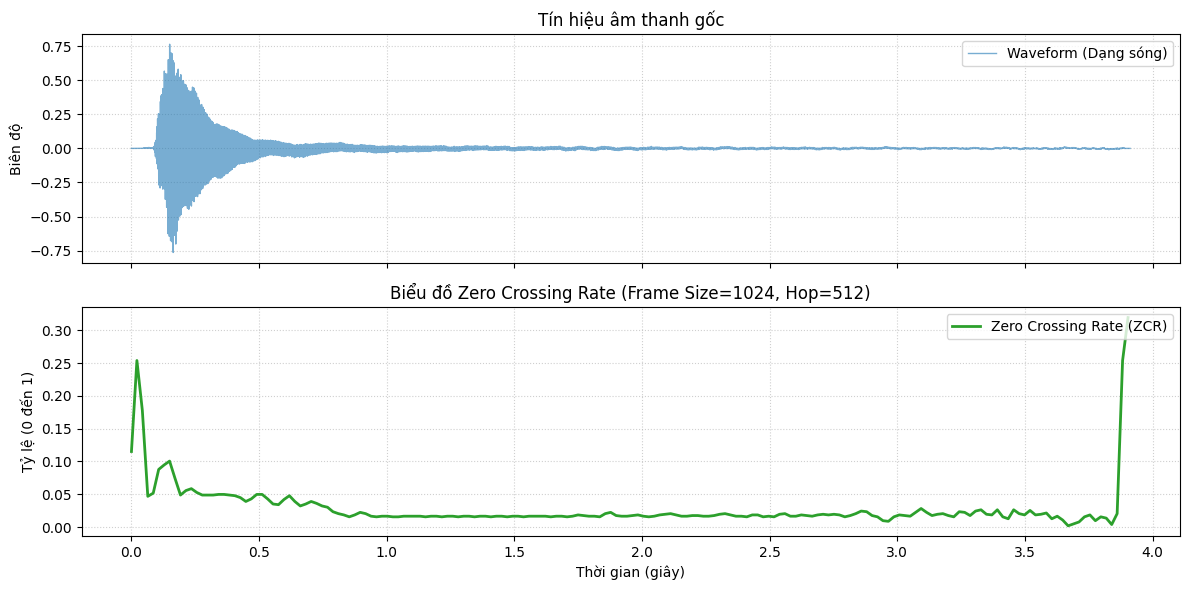

In [10]:
zcr, t_zcr = visualize_zero_crossing_rate(r"E:\s-recognition\data\freesound_community-violin-spiccato-g2-91380.mp3", start_sec=0, duration_sec=5)